# 🌷 Ejemplo resuelto · Proyecto **Centinela** — Fase 1: *Centinela del Tulipán*
### Redes Neuronales — Deep Learning · Maestría en Ciencia de Datos · Universidad Santo Tomás

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JotaMao1985/Deep_Learning_Usta/blob/main/notebooks/05-ejemplo-centinela-fase1-tulipanes.ipynb)

Este cuaderno es un **ejemplo resuelto de principio a fin** de la Fase 1 del Proyecto Integrador *Centinela*, construido sobre un problema **distinto** al que cada estudiante debe proponer: muestra **el nivel de profundidad, justificación y honestidad** que la rúbrica describe como *Estratégico*. Acompaña al [andamiaje](02-scaffold-centinela-fase1.ipynb) (que enseña la *mecánica* con datos sintéticos) mostrando cómo se ve esa mecánica **aplicada a datos reales**.

**El escenario.** Una cooperativa de cultivadores de bulbos de tulipán del **Noordoostpolder** (Flevoland, Países Bajos) pierde producción cuando una **helada nocturna tardía** (febrero–mayo) quema la flor y el follaje en pleno desarrollo del cultivo, comprometiendo la cosecha de bulbos de junio–julio. La cooperativa quiere una **alerta del día anterior** para activar a tiempo el riego anti-helada y las cubiertas térmicas. La Fase 1 construye la **línea base tabular con MLP**: predecir, con las variables meteorológicas de **hoy**, si **mañana** habrá helada ($T_{min} < 0\,°C$).

> ⛔ **Este escenario queda VETADO como entrega.** A diferencia del escenario de referencia del café (adoptable porque *no* está resuelto), este problema ya está resuelto aquí públicamente: adoptarlo —con esta estación, esta etiqueta o una variación menor— **no supera el *gate* de la Propuesta de Datos**. El valor de este cuaderno es el **estándar de calidad**, no el problema.

> 💡 **Cómo leer este cuaderno.** Cada sección replica la sección homónima del andamiaje. Lo que allí era `# TODO (estudiante)`, aquí está resuelto **y justificado**: la rúbrica no pide solo código que corra, sino **decisiones argumentadas** (cada hallazgo del EDA decide algo; cada elección de diseño cita su porqué).

---
**Contenido**
0. Preparación del entorno
1. El problema y los datos reales (KNMI · estación 273 Marknesse)
2. Exploración mínima (EDA) → cada hallazgo decide algo
3. Arquitectura del MLP (≥ 2 capas ocultas, salida en *logit*)
4. Pérdida, optimizador y bucle de entrenamiento explícito (50 épocas)
5. Funciones de diagnóstico y curvas de la línea base
6. Desafío · Inducir y corregir el sobreajuste con *Dropout*
7. Evaluación en prueba, análisis de errores y ética
8. Cierre · Autoevaluación contra la rúbrica
Anexo A · Auditoría a la IA: un fallo real, reproducido y corregido
Anexo B · Propuesta de Datos (el documento de 1 página que pasó el *gate*)
Anexo C · Bitácora de IA (diligenciada con los casos reales de esta construcción)
Anexo D · Informe técnico-ético (modelo de los entregables ≤ 4 páginas)


## 0. Preparación del entorno

Se importan las librerías del curso (`numpy`, `pandas`, `scikit-learn`, `matplotlib`, **PyTorch**) y se fijan **las dos semillas** (la de `numpy` y la de `torch`): sin ambas, los resultados no son reproducibles y la discusión de las curvas pierde sentido. La paleta y el formato de miles siguen la convención del material del curso.

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 1 · Preparación del entorno
# Qué hace · Importa librerías, fija las DOS semillas (numpy y torch) y configura el estilo.
# Por qué  · Reproducibilidad total: mismas semillas -> mismas curvas -> misma discusión.

# En Colab todas vienen instaladas. Si faltara alguna, descomentar:
# !pip -q install torch scikit-learn pandas matplotlib

%matplotlib inline
import io, os, urllib.request, urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

# Paleta USTA para las gráficas
USTA_MORADO, USTA_ROSA, USTA_NAVY = "#3D008D", "#ED1E79", "#001A4D"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

def miles(n):
    '''Formatea un entero con punto como separador de miles (p. ej. 1.234.567).'''
    return f"{n:,}".replace(",", ".")

print("Entorno listo · torch", torch.__version__, "· pandas", pd.__version__)


Entorno listo · torch 2.12.0 · pandas 2.3.3


## 1. El problema y los datos reales

**Resumen de la Propuesta de Datos aprobada** (el documento completo de 1 página acompaña esta entrega):

| Elemento | Decisión |
|---|---|
| **Cliente** | Cooperativa de cultivadores de bulbos de tulipán del Noordoostpolder (Flevoland, NL). |
| **Evento de riesgo** | Helada nocturna ($T_{min}<0\,°C$) **del día siguiente** durante la campaña de floración (1 feb – 15 may), que daña flor/follaje y compromete la cosecha de bulbos. |
| **Rama temporal** | Serie diaria de la estación **KNMI 273 Marknesse** (dentro del polder), 1989–2025: temperaturas, humedad, precipitación, viento, radiación. Datos abiertos KNMI. |
| **Rama de imagen** (Fase 2) | **Sentinel-2** (Copernicus Data Space): parches del polder para estado del cultivo/floración. Revisita ~5 días. |
| **Qué se aplana en Fase 1** | **La serie temporal** → tabla (variables del día $t$ + rezagos) con etiqueta en $t{+}1$. En la Fase 2, la RNN/LSTM consumirá la **secuencia completa** y la CNN aportará la rama visual, con clave de alineación agregada **(zona del polder, semana)**. |

> 🌷 **Contraste pedagógico con el escenario del café:** allí se aplana la **imagen** (foto de hoja → promedios RGB); aquí se aplana la **serie** (ventana de clima → features del día). Ambas rutas de aplanamiento son válidas para la Fase 1 — la Propuesta de Datos debe **declarar cuál** y por qué.

**Carga robusta.** La celda siguiente intenta tres fuentes en orden: (1) el CSV cacheado del repositorio del curso —reproducibilidad—, (2) la **API pública del KNMI** (sin token), (3) el espejo *raw* de GitHub. El rango se fija a `1989-01-01 → 2025-12-31` para que los conteos del cuaderno sean reproducibles.

> ⚠️ **El dato llega crudo, y eso es deliberado.** El KNMI entrega temperaturas en **décimas de grado**, codifica la llovizna (<0.05 mm) como **−1** y trae **celdas vacías**. Ninguna de esas tres cosas se "arregla sola": cada una exige una decisión documentada (sección 2).

In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 2 · Carga de los datos KNMI (cache -> API -> espejo GitHub)
# Qué hace · Obtiene la serie diaria 1989-2025 de la estación 273 Marknesse y la parsea.
# Por qué  · Triple fuente = el cuaderno corre igual en local, en Colab y si la API cambia.

KNMI_API   = "https://daggegevens.knmi.nl/klimatologie/daggegevens"
PARAMS     = {"stns": "273", "start": "19890101", "end": "20251231",
              "vars": "TG:TN:TX:UG:RH:FG:Q"}
CACHE_LOCAL = "data/knmi_273_marknesse.csv"
ESPEJO_RAW  = ("https://raw.githubusercontent.com/JotaMao1985/Deep_Learning_Usta/"
               "main/notebooks/data/knmi_273_marknesse.csv")
COLUMNAS = ["STN", "FECHA", "TG", "TN", "TX", "UG", "RH", "FG", "Q"]

def cargar_knmi():
    if os.path.exists(CACHE_LOCAL):
        with open(CACHE_LOCAL, encoding="utf-8") as f:
            return f.read(), "cache local del repositorio"
    try:
        datos = urllib.parse.urlencode(PARAMS).encode()
        with urllib.request.urlopen(KNMI_API, data=datos, timeout=60) as r:
            return r.read().decode("utf-8"), "API del KNMI (en vivo)"
    except Exception as e:
        print("API KNMI no disponible:", e)
        with urllib.request.urlopen(ESPEJO_RAW, timeout=60) as r:
            return r.read().decode("utf-8"), "espejo raw de GitHub"

crudo, fuente = cargar_knmi()

# Las líneas '#' son metadatos del KNMI (estación, definición de variables, avisos).
df = pd.read_csv(io.StringIO(crudo), comment="#", header=None, names=COLUMNAS,
                 skipinitialspace=True)
df["FECHA"] = pd.to_datetime(df["FECHA"], format="%Y%m%d")
df = df.drop(columns="STN").sort_values("FECHA").reset_index(drop=True)

print(f"Fuente usada : {fuente}")
print(f"Días cargados: {miles(len(df))}  ({df['FECHA'].min().date()} → {df['FECHA'].max().date()})")
df.head(3)


Fuente usada : cache local del repositorio
Días cargados: 13.514  (1989-01-01 → 2025-12-31)


,FECHA,TG,TN,TX,UG,RH,FG,Q
0,1989-01-01,NaN,53.0,78.0,NaN,NaN,21.0,NaN
1,1989-01-02,NaN,40.0,73.0,NaN,NaN,21.0,NaN
2,1989-01-03,NaN,5.0,50.0,NaN,NaN,41.0,NaN


## 2. Exploración mínima (EDA) → cada hallazgo decide algo

El EDA de la Fase 1 no es un trámite de gráficas: es la **fuente de las decisiones** de preprocesamiento y partición. Se revisan, en orden: (a) **faltantes** por variable y por época, (b) **escalas y codificaciones** del KNMI, (c) la **etiqueta** y su balance, (d) la **estacionalidad** del fenómeno.

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 3 · Hallazgo (a): faltantes por variable y por época
# Qué hace · Cuenta celdas vacías por columna y localiza en qué años se concentran.
# Por qué  · Decidir entre imputar o descartar exige saber CUÁNTO falta y DÓNDE.

faltantes = df.drop(columns="FECHA").isna().sum()
print("Celdas vacías por variable:")
print(faltantes.to_string())
print(f"\nTotal de celdas vacías: {miles(int(faltantes.sum()))}")

por_anio = df.set_index("FECHA").isna().groupby(lambda d: d.year).sum().sum(axis=1)
con_faltantes = por_anio[por_anio > 0]
print(f"\nAños con faltantes ({len(con_faltantes)} años):")
print(con_faltantes.to_string())


Celdas vacías por variable:
TG     310
TN      11
TX      11
UG     349
RH     417
FG       6
Q     1726

Total de celdas vacías: 2.830

Años con faltantes (8 años):
FECHA
1989    1307
1990     499
1991     377
1992     366
1993     268
1994       2
1998       5
2007       6


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 4 · Hallazgo (b): escalas y codificaciones -> conversión de unidades
# Qué hace · Pasa décimas a unidades físicas y resuelve la codificación RH = -1.
# Por qué  · Un MLP alimentado con décimas de grado "funciona", pero toda la
#            interpretación (¿helada = TN < 0?) se rompe si no se convierte.

# KNMI: TG/TN/TX en 0.1 °C · RH en 0.1 mm (con -1 = llovizna < 0.05 mm) · FG en 0.1 m/s
print("Antes  :", df[["TN", "RH"]].describe().loc[["min", "max"]].round(0).to_dict())

df["RH"] = df["RH"].replace(-1, 0)            # decisión: llovizna <0.05 mm ≈ 0 mm
for col in ["TG", "TN", "TX", "RH", "FG"]:
    df[col] = df[col] / 10.0                  # décimas -> °C, mm, m/s

print("Después:", df[["TN", "RH"]].describe().loc[["min", "max"]].round(1).to_dict())
print("\nRangos por variable (ya en unidades físicas):")
print(df.drop(columns="FECHA").describe().loc[["min", "mean", "max"]].round(1).to_string())


Antes  : {'TN': {'min': -228.0, 'max': 224.0}, 'RH': {'min': -1.0, 'max': 1156.0}}
Después: {'TN': {'min': -22.8, 'max': 22.4}, 'RH': {'min': 0.0, 'max': 115.6}}

Rangos por variable (ya en unidades físicas):
        TG    TN    TX     UG     RH    FG       Q
min  -14.8 -22.8 -10.6   35.0    0.0   0.8    16.0
mean  10.2   6.4  14.1   83.9    2.2   4.2  1032.9
max   28.7  22.4  38.1  100.0  115.6  15.4  3076.0


Días de campaña con etiqueta: 3.857
Heladas en t+1: 707 (18.3 %)  ←  clase MINORITARIA


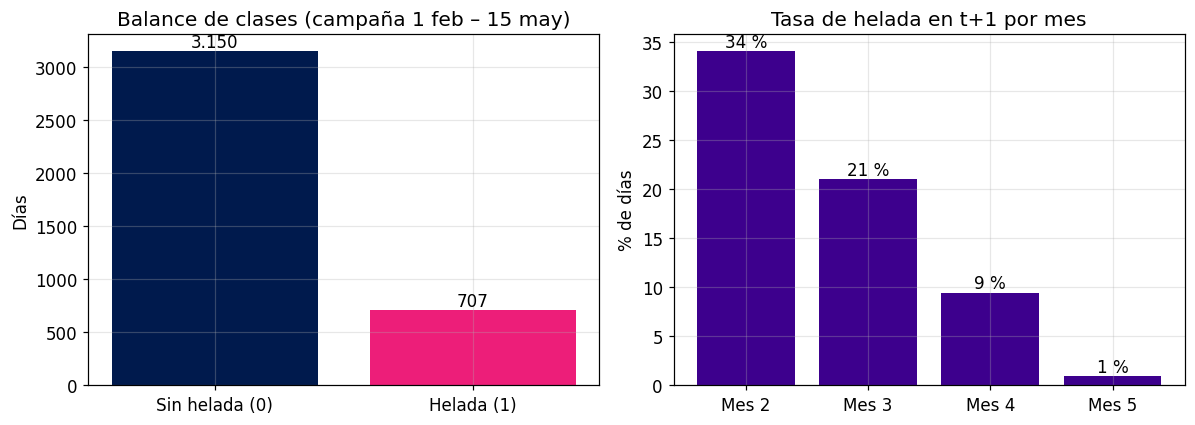

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 5 · Hallazgos (c) y (d): etiqueta, balance de clases y estacionalidad
# Qué hace · Construye la etiqueta "helada mañana", filtra la campaña y grafica balance + estacionalidad.
# Por qué  · El balance condiciona la lectura de métricas; la estacionalidad justifica
#            tanto la ventana de campaña como las features de calendario.

# Etiqueta: TN del día SIGUIENTE < 0 °C. shift(-1) sólo es válido si el día
# siguiente es consecutivo; se verifica la continuidad del calendario.
df["TN_manana"] = df["TN"].shift(-1)
dia_sig_ok = df["FECHA"].diff(-1).eq(pd.Timedelta(days=-1))
df.loc[~dia_sig_ok, "TN_manana"] = np.nan
df["helada_manana"] = (df["TN_manana"] < 0).astype(float)
df.loc[df["TN_manana"].isna(), "helada_manana"] = np.nan

# Campaña de floración: 1 de febrero a 15 de mayo (fenología del tulipán en NL).
md_ini, md_fin = (2, 1), (5, 15)
clave_md = list(zip(df["FECHA"].dt.month, df["FECHA"].dt.day))
df["en_campana"] = [(md_ini <= md <= md_fin) for md in clave_md]

campana = df[df["en_campana"] & df["helada_manana"].notna()]
n_pos = int(campana["helada_manana"].sum())
print(f"Días de campaña con etiqueta: {miles(len(campana))}")
print(f"Heladas en t+1: {miles(n_pos)} ({100 * n_pos / len(campana):.1f} %)  ←  clase MINORITARIA")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
conteo = campana["helada_manana"].value_counts().sort_index()
ax1.bar(["Sin helada (0)", "Helada (1)"], conteo.values, color=[USTA_NAVY, USTA_ROSA])
for i, v in enumerate(conteo.values):
    ax1.text(i, v, miles(int(v)), ha="center", va="bottom")
ax1.set_title("Balance de clases (campaña 1 feb – 15 may)")
ax1.set_ylabel("Días")

tasa_mes = campana.groupby(campana["FECHA"].dt.month)["helada_manana"].mean() * 100
ax2.bar([f"Mes {m}" for m in tasa_mes.index], tasa_mes.values, color=USTA_MORADO)
for i, v in enumerate(tasa_mes.values):
    ax2.text(i, v, f"{v:.0f} %", ha="center", va="bottom")
ax2.set_title("Tasa de helada en t+1 por mes")
ax2.set_ylabel("% de días")
plt.tight_layout(); plt.show()


### Decisiones que deja el EDA

| # | Hallazgo | Decisión que toma |
|---|---|---|
| a | Solo ~3 % de las celdas están vacías, pero **no al azar**: 1.726 de las 2.830 son la radiación `Q`, concentradas en **1989–1993** (la estación aún no medía radiación de forma continua). | **Descartar las filas incompletas** (no imputar): con décadas de datos sobran muestras, y una imputación climática seria excede la Fase 1. El costo real es perder los primeros años: la tabla útil **arranca en 1994** (24 campañas de entrenamiento, no 29). La celda 6 reporta la cifra exacta. |
| b | Temperaturas en **décimas de grado** y llovizna codificada como **−1**. | Convertir unidades **antes** de tocar la etiqueta (helada = $T_{min}<0$ exige °C reales) y mapear $-1 \to 0$ mm, decisión declarada (la llovizna es operativamente "no lluvia"). |
| c | La clase *helada* es **minoritaria (~18 %)**. | La **exactitud global queda descartada** como métrica de cabecera: un modelo que siempre diga "no habrá helada" acierta ~82 % y es inútil. Se evaluará con matriz de confusión y **recall de la clase helada** (sección 7). |
| d | La helada **decae de febrero a mayo** (estacionalidad fuerte). | Añadir **features de calendario** ($\sin/\cos$ del día del año) para que el MLP, que no ve fechas, reciba la señal estacional. |

### Partición train / val / test: **por años**, no aleatoria

Los días consecutivos de una serie climática están **autocorrelacionados**: si el 3 y el 4 de abril de 1995 cayeran uno en *train* y otro en *test*, el modelo sería evaluado sobre información casi idéntica a la que memorizó — una **fuga temporal** que infla las métricas. Por eso la partición es **por campañas completas (años)**:

| Partición | Años | Uso |
|---|---|---|
| **Entrenamiento** | ≤ 2017 (24 campañas útiles: 1994–2017) | Ajustar pesos |
| **Validación** | 2018–2021 (4 campañas) | Vigilar sobreajuste, elegir hiperparámetros |
| **Prueba** | 2022–2025 (4 campañas) | Tocar **una sola vez**, al final (sección 7) |

El escalado (`StandardScaler`) se ajusta **solo con el conjunto de entrenamiento** y se aplica a los otros dos: ajustarlo con todos los datos sería otra fuga (la media y la desviación de *test* se filtrarían al entrenamiento).

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 6 · Features, filtro de campaña, partición por años y escalado
# Qué hace · Construye la tabla final (features del día t + rezagos + calendario),
#            divide por años y estandariza ajustando SOLO con train.
# Por qué  · Aquí se materializan las cuatro decisiones del EDA y la regla anti-fuga.

# Rezagos: el clima de ayer también informa la helada de mañana (t-1 -> t+1).
for col in ["TN", "TG", "Q"]:
    df[f"{col}_ayer"] = df[col].shift(1)

# Calendario: estacionalidad como señal continua y periódica.
doy = df["FECHA"].dt.dayofyear
df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

FEATURES = ["TG", "TN", "TX", "UG", "RH", "FG", "Q",
            "TN_ayer", "TG_ayer", "Q_ayer", "doy_sin", "doy_cos"]

tabla = df[df["en_campana"]].dropna(subset=FEATURES + ["helada_manana"]).copy()
descartadas = int(df["en_campana"].sum() - len(tabla))
print(f"Tabla final: {miles(len(tabla))} muestras · {len(FEATURES)} features "
      f"(se descartaron {miles(descartadas)} filas de campaña con faltantes o sin etiqueta)")

anio = tabla["FECHA"].dt.year
m_train, m_val, m_test = anio <= 2017, anio.between(2018, 2021), anio >= 2022

X = tabla[FEATURES].to_numpy(dtype=np.float32)
y = tabla["helada_manana"].to_numpy(dtype=np.float32)

escalador = StandardScaler().fit(X[m_train])          # SOLO train: regla anti-fuga
X_train, y_train = escalador.transform(X[m_train]), y[m_train.to_numpy()]
X_val,   y_val   = escalador.transform(X[m_val]),   y[m_val.to_numpy()]
X_test,  y_test  = escalador.transform(X[m_test]),  y[m_test.to_numpy()]

for nombre, Xp, yp in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"  {nombre:5s}: {miles(len(Xp)):>6s} muestras · {100 * yp.mean():.1f} % helada")


Tabla final: 3.334 muestras · 12 features (se descartaron 523 filas de campaña con faltantes o sin etiqueta)
  train:  2.500 muestras · 19.4 % helada
  val  :    417 muestras · 18.2 % helada
  test :    417 muestras · 14.4 % helada


## 3. Arquitectura del MLP

La actividad exige **al menos dos capas ocultas**; aquí se usa la referencia de la ficha, $d \to 16 \to 8 \to 1$ (con $d = 12$ features):

- **ReLU en las ocultas.** La relación clima→helada no es lineal (la radiación importa distinto con viento que en calma; el cielo despejado enfría más en noches secas). Sin no-linealidad, dos capas colapsan en una sola transformación lineal — un MLP de cualquier profundidad sería equivalente a una regresión logística. ReLU, además, no satura en la zona positiva, lo que mantiene gradientes sanos (Cap. 2 y Cap. 4 del curso).
- **Salida en *logit* (sin sigmoide en el `forward`).** La última capa es `nn.Linear(8, 1)` y devuelve un número real $z$. La probabilidad $\sigma(z) = \frac{1}{1+e^{-z}}$ se calcula **solo en evaluación** con `torch.sigmoid`. La razón es numérica: la pérdida `BCEWithLogitsLoss` integra la sigmoide y la entropía cruzada en un único paso estable (*log-sum-exp*).
- **`Dropout` opcional en el constructor.** Con `p_dropout=0.0` la capa es inocua; la sección 6 reutiliza **la misma clase** para el experimento de regularización, sin duplicar código.

> ⚠️ **Antipatrón vetado: la doble sigmoide.** Si el modelo terminara en `nn.Sigmoid()` **y** se entrenara con `BCEWithLogitsLoss`, la salida pasaría dos veces por $\sigma$ y el gradiente se aplastaría. El Anexo A **reproduce este fallo a propósito** —fue un error real de la IA asistente durante la construcción de este ejemplo— y muestra su firma en las curvas.

In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 7 · Arquitectura: MLP 12 -> 16 -> 8 -> 1 (salida en logit)
# Qué hace · Define la clase del modelo con dos capas ocultas ReLU y Dropout opcional.
# Por qué  · El logit (sin sigmoide aquí) es la pareja correcta de BCEWithLogitsLoss.

class CentinelaMLP(nn.Module):
    '''MLP para clasificación binaria: d_entrada -> 16 -> 8 -> 1 (logit).

    La salida NO pasa por sigmoide dentro del modelo: devuelve el logit z.
    La probabilidad sigma(z) se obtiene con torch.sigmoid SOLO en evaluación.
    '''

    def __init__(self, d_entrada, oculta1=16, oculta2=8, p_dropout=0.0):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(d_entrada, oculta1), nn.ReLU(), nn.Dropout(p_dropout),
            nn.Linear(oculta1, oculta2),  nn.ReLU(), nn.Dropout(p_dropout),
            nn.Linear(oculta2, 1),        # logit: SIN activación final
        )

    def forward(self, x):
        return self.red(x)

modelo = CentinelaMLP(d_entrada=len(FEATURES))
n_params = sum(p.numel() for p in modelo.parameters())
print(modelo)
print(f"\nParámetros entrenables: {miles(n_params)}")


CentinelaMLP(
  (red): Sequential(
    (0): Linear(in_features=12, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

Parámetros entrenables: 353


## 4. Pérdida, optimizador y bucle de entrenamiento explícito

- **Pérdida:** `nn.BCEWithLogitsLoss()` — entropía cruzada binaria que **recibe logits**. Exige que la etiqueta tenga la **misma forma que el logit**, `(N, 1)`, y sea flotante: de ahí el `view(-1, 1)` del helper `a_tensor`. Omitirlo no lanza error: produce un *broadcasting* silencioso que entrena mal sin avisar (caso documentado en la Bitácora de IA).
- **Optimizador:** `Adam` con tasa de aprendizaje $10^{-2}$ — **un ajuste justificado**, como permite la ficha ("50 épocas, ajustable con justificación"). La razón: este entrenamiento usa **lote completo**, de modo que cada época equivale a **un solo paso de gradiente**. Con la tasa típica de $10^{-3}$, 50 pasos dejan el modelo a medio descender (se verificó: pérdida de validación ≈ 0.60 y aún bajando); con $10^{-2}$, los mismos 50 pasos llegan a ≈ 0.25. Frente a SGD puro, Adam adapta además la tasa por parámetro — apropiado para una línea base; el curso vuelve sobre SGD/momentum en el laboratorio del Módulo 1.
- **Bucle explícito.** La actividad pide escribir los **cinco pasos** a mano (sin `model.fit`), porque cada uno es un concepto del Cap. 4: `zero_grad` → *forward* → pérdida → `backward` → `step`.
- **Guardado periódico.** Colab puede desconectarse; cada 10 épocas se guarda `state_dict` (la ficha lo recomienda — aquí el entrenamiento tarda segundos, pero el hábito se ensaya donde no cuesta).

In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 8 · Tensores, pérdida, optimizador y bucle de entrenamiento (50 épocas)
# Qué hace · Convierte datos a tensores y entrena registrando pérdida train/val por época.
# Por qué  · El bucle explícito de 5 pasos ES el contenido evaluable del Cap. 4.

def a_tensor(Xa, ya):
    return (torch.tensor(Xa, dtype=torch.float32),
            torch.tensor(ya, dtype=torch.float32).view(-1, 1))   # forma (N,1): pareja del logit

X_train_t, y_train_t = a_tensor(X_train, y_train)
X_val_t,   y_val_t   = a_tensor(X_val,   y_val)
X_test_t,  y_test_t  = a_tensor(X_test,  y_test)

def entrenar(modelo, X_tr, y_tr, X_va, y_va, epocas=50, lr=1e-3,
             ruta_checkpoint=None, verboso=True):
    '''Bucle de entrenamiento explícito. Devuelve (hist_train, hist_val).'''
    criterio = nn.BCEWithLogitsLoss()
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    hist_train, hist_val = [], []
    for epoca in range(1, epocas + 1):
        modelo.train()
        optimizador.zero_grad()            # 1) limpiar gradientes acumulados
        logits = modelo(X_tr)              # 2) forward
        perdida = criterio(logits, y_tr)   # 3) pérdida
        perdida.backward()                 # 4) backward (gradientes)
        optimizador.step()                 # 5) actualizar pesos
        hist_train.append(perdida.item())

        modelo.eval()                      # validación: sin dropout y sin gradientes
        with torch.no_grad():
            hist_val.append(criterio(modelo(X_va), y_va).item())

        if ruta_checkpoint and epoca % 10 == 0:
            torch.save(modelo.state_dict(), ruta_checkpoint)
        if verboso and (epoca % 10 == 0 or epoca == 1):
            print(f"Época {epoca:3d} · pérdida train {hist_train[-1]:.4f} · val {hist_val[-1]:.4f}")
    return hist_train, hist_val

hist_train, hist_val = entrenar(modelo, X_train_t, y_train_t, X_val_t, y_val_t,
                                epocas=50, lr=1e-2,   # lote completo: 1 paso/época -> lr alto justificado
                                ruta_checkpoint="centinela_fase1_tulipan.pt")


Época   1 · pérdida train 0.7615 · val 0.7335
Época  10 · pérdida train 0.5025 · val 0.4575
Época  20 · pérdida train 0.3112 · val 0.2940
Época  30 · pérdida train 0.2772 · val 0.2597
Época  40 · pérdida train 0.2573 · val 0.2542
Época  50 · pérdida train 0.2410 · val 0.2509


## 5. Funciones de diagnóstico y curvas de la línea base

Los dos *helpers* son **idénticos** a los del andamiaje (`plot_curvas_perdida`, `plot_matriz_confusion`): no dependen de PyTorch y funcionan con cualquier historial. Se aplican de inmediato al entrenamiento de la sección 4.

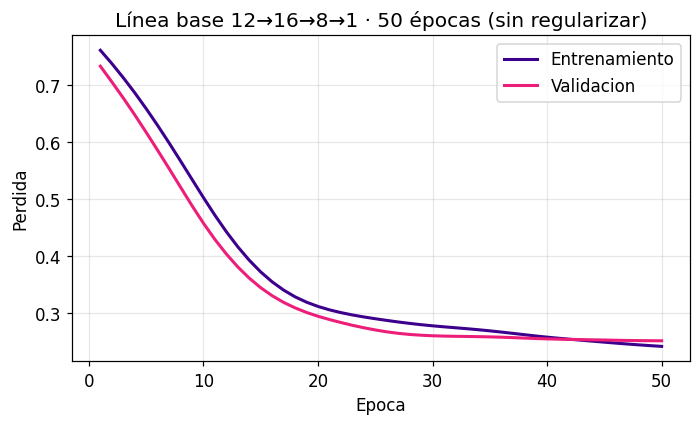

Pérdida final · train 0.2410 · val 0.2509


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 9 · Funciones de diagnóstico (idénticas al andamiaje) + curvas de la línea base
# Qué hace · Define los helpers de graficado y muestra las curvas del run de 50 épocas.
# Por qué  · La brecha train/val es la firma del sobreajuste; aquí se lee su ausencia.

def plot_curvas_perdida(train_losses, val_losses, titulo="Curva de perdida"):
    '''Grafica la pérdida de entrenamiento frente a la de validación por época.'''
    train_losses = np.asarray(train_losses, dtype=float)
    val_losses = np.asarray(val_losses, dtype=float)
    epocas = np.arange(1, len(train_losses) + 1)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(epocas, train_losses, color=USTA_MORADO, lw=2, label="Entrenamiento")
    ax.plot(epocas, val_losses, color=USTA_ROSA, lw=2, label="Validacion")
    ax.set_xlabel("Epoca"); ax.set_ylabel("Perdida")
    ax.set_title(titulo); ax.legend()
    plt.tight_layout(); plt.show()


def plot_matriz_confusion(y_true, y_pred, etiquetas=("Clase 0", "Clase 1"),
                          titulo="Matriz de confusion"):
    '''Dibuja la matriz de confusión (2x2) con sus conteos anotados.'''
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.4, 4))
    im = ax.imshow(cm, cmap="Purples")
    ax.set_xticks([0, 1], labels=etiquetas)
    ax.set_yticks([0, 1], labels=etiquetas)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Valor real")
    ax.set_title(titulo)
    umbral = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(2):
        for j in range(2):
            ax.text(j, i, miles(int(cm[i, j])), ha="center", va="center",
                    color="white" if cm[i, j] > umbral else "black", fontsize=13)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.grid(False)
    plt.tight_layout(); plt.show()

plot_curvas_perdida(hist_train, hist_val,
                    titulo="Línea base 12→16→8→1 · 50 épocas (sin regularizar)")
print(f"Pérdida final · train {hist_train[-1]:.4f} · val {hist_val[-1]:.4f}")


**Lectura de las curvas.** Las dos pérdidas descienden **juntas** (de ≈ 0.76/0.73 en la época 1 a **0.2410 / 0.2509** en la 50) y la de validación alcanza su mínimo **en la última época**: no hay sobreajuste — la brecha final es de apenas ~0.01 y la curva de validación nunca cruza al alza. Coherente con la capacidad del modelo: **353 parámetros** para 2.500 muestras. Esto significa también que el fenómeno que la actividad pide estudiar **no aparece solo**: hay que inducirlo (sección 6).

## 6. Desafío · Inducir y corregir el sobreajuste con *Dropout*

La línea base no sobreajusta, así que el fenómeno hay que **fabricarlo** para estudiarlo — exactamente lo que pide la actividad. Receta clásica: **más capacidad** (red $128 \to 64$: 9.985 parámetros, ~28 veces los 353 de la línea base), **más épocas** (400) y **menos datos** (solo las 3 primeras campañas disponibles —1994–1996, 311 muestras—; "disponibles" porque el EDA mostró que 1989–1993 cayeron con los faltantes de radiación). Así el modelo tiene parámetros de sobra para *memorizar* en vez de *generalizar*.

Después se corrige con **las dos palancas que la ficha sugiere, juntas**: la misma red con **`Dropout(0.5)`** (en cada paso se apaga al azar la mitad de las neuronas ocultas, de modo que ninguna puede especializarse en memorizar una muestra concreta — Cap. 5) **y la tasa de aprendizaje de vuelta a $10^{-3}$** (pasos diez veces más pequeños: a la red le cuesta mucho más precipitarse al fondo del mínimo memorizado). Se verificó por separado que el Dropout **solo**, manteniendo $lr = 10^{-2}$, no basta aquí: con 400 pasos grandes la red memoriza igual — un hallazgo honesto que muestra por qué la regularización se piensa como sistema y no como ingrediente mágico.

Subconjunto reducido: 311 muestras (3 primeras campañas disponibles: [1994, 1995, 1996])
Parámetros de la red grande: 9.985


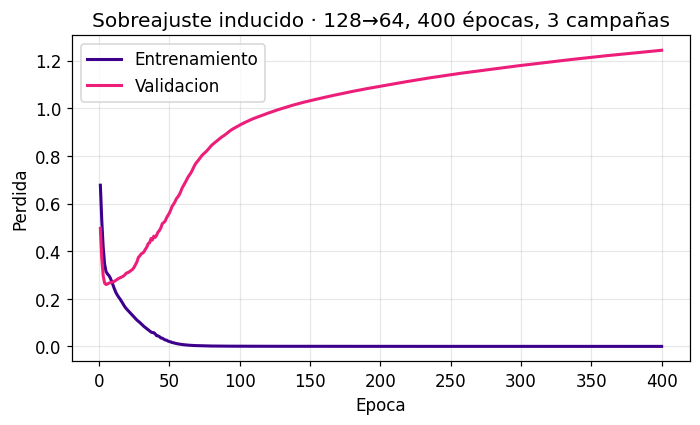

Mínimo de la pérdida de validación: época 5 (val 0.2601); al final (época 400): val 1.2442
Brecha final train↔val: 1.2442


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 10 · Inducir el sobreajuste: red grande + pocas muestras + 400 épocas
# Qué hace · Entrena 128->64 sobre solo 3 campañas y grafica la divergencia train/val.
# Por qué  · Ver la pérdida de validación CRUZAR AL ALZA es el objetivo del desafío.

# Las 3 primeras campañas DISPONIBLES (el EDA eliminó 1989-1993 por faltantes de Q).
anios_train = tabla[m_train.to_numpy()]["FECHA"].dt.year
anios_sub = sorted(anios_train.unique())[:3]
msub = anios_train.isin(anios_sub).to_numpy()
X_poco_t, y_poco_t = a_tensor(X_train[msub], y_train[msub])
print(f"Subconjunto reducido: {miles(int(msub.sum()))} muestras "
      f"(3 primeras campañas disponibles: {[int(x) for x in anios_sub]})")

torch.manual_seed(SEMILLA)   # misma semilla antes de CADA experimento: comparaciones limpias
grande = CentinelaMLP(len(FEATURES), oculta1=128, oculta2=64, p_dropout=0.0)
print(f"Parámetros de la red grande: {miles(sum(p.numel() for p in grande.parameters()))}")

hist_tr_sobre, hist_va_sobre = entrenar(grande, X_poco_t, y_poco_t, X_val_t, y_val_t,
                                        epocas=400, lr=1e-2, verboso=False)
plot_curvas_perdida(hist_tr_sobre, hist_va_sobre,
                    titulo="Sobreajuste inducido · 128→64, 400 épocas, 3 campañas")
ep_min_sobre = int(np.argmin(hist_va_sobre)) + 1
print(f"Mínimo de la pérdida de validación: época {ep_min_sobre} "
      f"(val {min(hist_va_sobre):.4f}); al final (época 400): val {hist_va_sobre[-1]:.4f}")
print(f"Brecha final train↔val: {hist_va_sobre[-1] - hist_tr_sobre[-1]:.4f}")


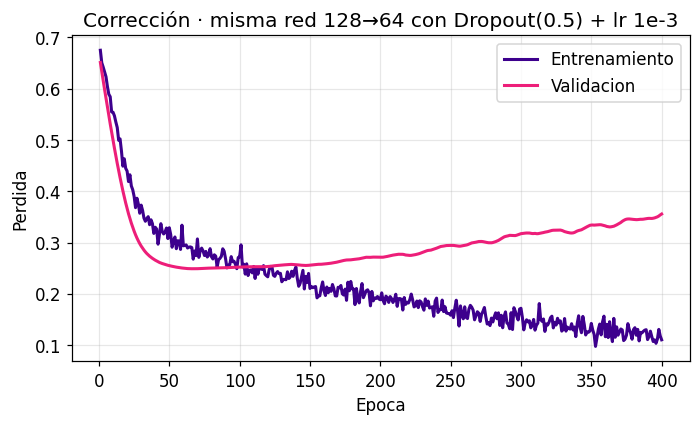

Mínimo de validación: época 67 (val 0.2489); al final: val 0.3556
Brecha final train↔val: 0.2453 (sin dropout era 1.2442)


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 11 · Corregir con Dropout(0.5) + lr 1e-3: misma red, mismos datos, mismas épocas
# Qué hace · Repite el experimento aplicando las DOS palancas de la ficha y compara curvas.
# Por qué  · Se verificó que el Dropout solo (con lr 1e-2) no basta: la corrección es un sistema.

torch.manual_seed(SEMILLA)
regularizada = CentinelaMLP(len(FEATURES), oculta1=128, oculta2=64, p_dropout=0.5)
hist_tr_reg, hist_va_reg = entrenar(regularizada, X_poco_t, y_poco_t, X_val_t, y_val_t,
                                    epocas=400, lr=1e-3, verboso=False)
plot_curvas_perdida(hist_tr_reg, hist_va_reg,
                    titulo="Corrección · misma red 128→64 con Dropout(0.5) + lr 1e-3")
ep_min_reg = int(np.argmin(hist_va_reg)) + 1
print(f"Mínimo de validación: época {ep_min_reg} (val {min(hist_va_reg):.4f}); "
      f"al final: val {hist_va_reg[-1]:.4f}")
print(f"Brecha final train↔val: {hist_va_reg[-1] - hist_tr_reg[-1]:.4f} "
      f"(sin dropout era {hist_va_sobre[-1] - hist_tr_sobre[-1]:.4f})")


**Lectura del experimento.** En la versión sin regularizar, la pérdida de entrenamiento cae a **≈ 0.0001** —la red *memorizó* las 311 muestras— mientras la de validación **cruza al alza casi de inmediato** y termina en **≈ 1.24**: cinco veces peor que su propio mínimo. Esa tijera abierta es la firma visual del sobreajuste. Con `Dropout(0.5)` + $lr = 10^{-3}$, la pérdida de entrenamiento ya no llega a cero (≈ 0.11: la red **no puede** memorizar con la mitad de las neuronas apagándose) y la brecha final se reduce **de ≈ 1.24 a ≈ 0.25**, con una curva de validación que sube suave en lugar de dispararse.

> 💡 **El punto óptimo tiene época y nombre.** Sin regularizar, la validación toca su mínimo en la **época 5** (≈ 0.260) y a partir de ahí todo es memorización. Con la corrección, el mínimo llega en la **época 67** y es **mejor** (≈ 0.249): la regularización no solo frenó el desastre — le dio a la red más margen para aprender de verdad. Detener el entrenamiento en el mínimo —*early stopping*— habría sido la otra corrección válida; la corrección aplicada consigue algo mejor: que seguir entrenando degrade mucho menos.

**Modelo elegido para la evaluación final:** la línea base $12 \to 16 \to 8 \to 1$ de la sección 4. Su pérdida de validación (0.2509) es prácticamente la misma que el mejor punto de la red grande regularizada (0.2489), no muestra señales de sobreajuste con los datos completos, y tiene 28 veces menos parámetros: **a igual desempeño, gana el modelo más simple**.

## 7. Evaluación en prueba, análisis de errores y ética

El conjunto de **prueba (2022–2025) se toca por primera y única vez aquí**. Como el modelo devuelve **logits**, se aplica `torch.sigmoid` —ahora sí— para obtener probabilidades, y se umbraliza en 0.5 para producir la clase. Dado el desbalance (~18 % de heladas), la lectura se centra en la **matriz de confusión** y el ***recall* de la clase helada**, no en la exactitud global.

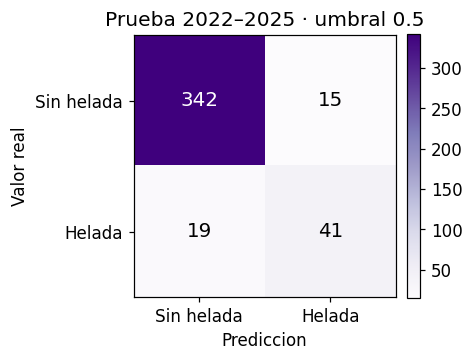

              precision    recall  f1-score   support

  Sin helada      0.947     0.958     0.953       357
      Helada      0.732     0.683     0.707        60

    accuracy                          0.918       417
   macro avg      0.840     0.821     0.830       417
weighted avg      0.916     0.918     0.917       417

Falsos negativos (helada NO avisada) : 19  ← el error caro para el cultivo
Falsos positivos (alarma sin helada) : 15  ← el error que erosiona la confianza


In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 12 · Evaluación en el conjunto de prueba (sigmoide SOLO aquí)
# Qué hace · Convierte logits en probabilidades, umbraliza en 0.5 y reporta matriz + métricas por clase.
# Por qué  · El recall de la clase 'helada' es la métrica que le importa al cliente.

modelo.eval()
with torch.no_grad():
    prob_test = torch.sigmoid(modelo(X_test_t)).numpy().ravel()   # logit -> probabilidad
y_pred = (prob_test >= 0.5).astype(int)

plot_matriz_confusion(y_test, y_pred, etiquetas=("Sin helada", "Helada"),
                      titulo="Prueba 2022–2025 · umbral 0.5")
print(classification_report(y_test, y_pred, target_names=["Sin helada", "Helada"], digits=3))

cm = confusion_matrix(y_test, y_pred)
vn, fp, fn, vp = cm.ravel()
print(f"Falsos negativos (helada NO avisada) : {fn}  ← el error caro para el cultivo")
print(f"Falsos positivos (alarma sin helada) : {fp}  ← el error que erosiona la confianza")


In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 13 · El umbral es una decisión del cliente, no del algoritmo
# Qué hace · Compara recall y falsas alarmas para tres umbrales de probabilidad.
# Por qué  · Bajar el umbral compra recall (menos heladas perdidas) pagando falsas alarmas.

print(f"{'Umbral':>7} | {'Recall helada':>13} | {'Precision helada':>16} | {'FN':>3} | {'FP':>4}")
for umbral in (0.50, 0.35, 0.20):
    pred_u = (prob_test >= umbral).astype(int)
    vn_u, fp_u, fn_u, vp_u = confusion_matrix(y_test, pred_u).ravel()
    rec = vp_u / (vp_u + fn_u)
    pre = vp_u / (vp_u + fp_u) if (vp_u + fp_u) else float("nan")
    print(f"{umbral:7.2f} | {rec:13.3f} | {pre:16.3f} | {fn_u:3d} | {fp_u:4d}")


 Umbral | Recall helada | Precision helada |  FN |   FP
   0.50 |         0.683 |            0.732 |  19 |   15
   0.35 |         0.800 |            0.623 |  12 |   29
   0.20 |         0.883 |            0.546 |   7 |   44


### Lectura técnica y ética de los errores

De las **60 heladas reales** de las campañas 2022–2025, el modelo **avisó 41 y calló 19** con el umbral estándar de 0.5, al costo de **15 falsas alarmas**. La exactitud global (0.918) luce excelente, pero el EDA ya había advertido por qué no es la métrica de cabecera: con ~86 % de días sin helada, un modelo mudo acertaría casi lo mismo sin servir de nada. La métrica que le importa al cliente es el ***recall* de la clase helada: 0.683** — el sistema detecta 2 de cada 3 heladas y **falla 19 noches en 4 campañas**. La celda 13 muestra el menú de compromisos: bajando el umbral a 0.35 el *recall* sube a **0.800** (12 noches falladas) con 29 falsas alarmas, y en 0.20 llega a **0.883** (7 falladas) con 44.

Nótese además que la tasa de heladas del conjunto de prueba (14.4 %) es menor que la de entrenamiento (19.4 %): las primaveras recientes son más cálidas. Es un desplazamiento real del fenómeno (*drift* climático) que la Fase 3 deberá vigilar en producción.

**¿Qué error debe priorizar el cliente?** El **Marco Ético para la IA en Colombia** (Minciencias, 2021) pide evaluar los sistemas por el **daño de sus errores sobre las personas**, no por su exactitud agregada. Aquí los dos errores no pesan lo mismo:

- **Falso negativo (helada no avisada).** La cooperativa no despliega el riego anti-helada y la flor se quema: se pierde producción del lote y trabajo de meses. El daño es **alto, concentrado e irreversible** — y recae con más fuerza en el cultivador pequeño, que no puede absorber una campaña perdida.
- **Falso positivo (alarma sin helada).** Se activa el riego una noche de más: costo de agua y energía, y —más corrosivo— **fatiga de alarma**: un sistema que "llora lobo" termina ignorado, y entonces sus aciertos también se pierden.

Conclusión operativa para este cliente: **priorizar el *recall* de la clase helada** (minimizar FN) y gobernar los FP **eligiendo el umbral con el cliente** — la celda 13 muestra ese menú de compromisos: bajar el umbral de 0.5 a 0.35 compra *recall* pagando falsas alarmas. Esa elección es una **decisión de negocio informada por el modelo**, no un hiperparámetro técnico.

> 🌎 **El mismo problema, en Colombia.** Las heladas de la Sabana de Bogotá golpean igual a la floricultura de exportación y a la papa de Boyacá y Cundinamarca: un Centinela como este, alimentado por estaciones del IDEAM, enfrentaría el mismo dilema FN/FP con los mismos actores vulnerables. El marco ético colombiano no es un requisito decorativo: describe exactamente este caso.

**Límites honestos de la línea base.** El MLP ve **un día y dos rezagos**: no puede leer la *trayectoria* de un frente frío que se instala durante varios días — para eso la Fase 2 reemplaza este aplanamiento por una **RNN/LSTM sobre la secuencia completa**, y añade la rama visual (Sentinel-2) para saber **cuánto cultivo está expuesto** cuando llega la helada. La línea base no es el final: es la vara contra la que la Fase 2 tendrá que justificarse.

## 8. Cierre · Autoevaluación contra la rúbrica

Cómo se distribuye la evidencia de este cuaderno (y sus anexos) en los **6 criterios** de la rúbrica de la Fase 1:

| Criterio (peso) | Dónde está la evidencia |
|---|---|
| 1. Propuesta de datos y EDA (15 %) | Propuesta de 1 página (**Anexo B**, resumida en §1); EDA con 4 hallazgos que **deciden** preprocesamiento y partición (§2). |
| 2. Diseño e implementación del MLP (30 %) | Clase con 2 capas ocultas justificadas, salida en logit, `BCEWithLogitsLoss`, `view(-1,1)`, semillas fijas, bucle explícito de 5 pasos (§3–§4); el cuaderno corre de principio a fin sin editar. |
| 3. Regularización y experimentación (15 %) | Sobreajuste inducido y corregido con Dropout, con **época del punto óptimo nombrada** (§6). |
| 4. Evaluación, errores y ética (15 %) | Matriz de confusión y métricas **por clase** sobre prueba intacta, `torch.sigmoid` solo en evaluación, análisis FN/FP anclado al Marco Ético (§7). |
| 5. Uso responsable de IA (15 %) | **Bitácora de IA** (**Anexo C**) con casos Aceptada/Modificada/Rechazada **reales de esta construcción**; **Auditoría** con fallo reproducido en el Anexo A. |
| 6. Comunicación y storytelling (10 %) | **Informe técnico-ético** (**Anexo D**, ≤ 4 págs.) con el hilo problema→modelo→error→decisión para audiencia no técnica. |

> ⛔ **Recordatorio del veto.** Este escenario (tulipanes / KNMI / helada) **no es adoptable** como entrega. La Propuesta de Datos de cada estudiante debe plantear un problema propio — el [Catálogo de Fuentes de Datos](https://jotamao1985.github.io/Deep_Learning_Usta/) ofrece decenas de combinaciones válidas.

### 🔗 Relacionado
- **Actividad evaluable:** Fase 1 · *Centinela* — ficha completa y rúbrica en el portal del curso.
- **Andamiaje (punto de partida):** `02-scaffold-centinela-fase1.ipynb`.
- **Documento maestro:** Proyecto Integrador Centinela (las tres fases).
- **Material teórico:** Módulo 1 — Capítulos 2 (MLP), 3 (optimización), 4 (retropropagación) y 5 (regularización y ética).
- **Datos:** Koninklijk Nederlands Meteorologisch Instituut (KNMI), *Daggegevens van het weer in Nederland*, estación 273 Marknesse — datos abiertos. https://daggegevens.knmi.nl/
- **Marco normativo:** Minciencias (2021), *Marco Ético para la Inteligencia Artificial en Colombia*.

## Anexo A · Auditoría a la IA: la doble sigmoide, reproducida

Durante la construcción de este ejemplo, la IA asistente propuso un modelo que terminaba en `nn.Sigmoid()` **y a la vez** un entrenamiento con `BCEWithLogitsLoss` — el antipatrón exacto contra el que advierte la ficha. El código **corre sin errores** (por eso es peligroso): la pérdida interpreta probabilidades como si fueran logits, la sigmoide se aplica dos veces y el gradiente llega aplastado. La celda siguiente **reproduce el fallo en condiciones controladas** y lo compara con la versión correcta: misma red, misma semilla, mismos datos.

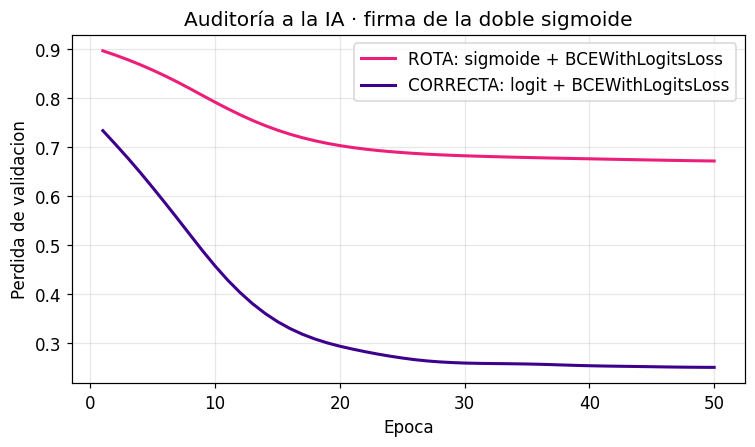

Pérdida de validación tras 50 épocas · rota: 0.6716 · correcta: 0.2509
La versión rota queda estancada: sus 'logits' viven en (0,1), la pérdida los
re-sigmoidea hacia sigma(0..1) ≈ (0.5, 0.73) y el gradiente útil desaparece.


In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 14 · Reproducción del fallo: sigmoide dentro del modelo + BCEWithLogitsLoss
# Qué hace · Entrena la versión ROTA y la CORRECTA con idéntica semilla y compara curvas.
# Por qué  · Auditar a la IA exige demostrar el fallo, no solo narrarlo.

class MLPConDobleSigmoide(nn.Module):
    '''Versión ROTA propuesta por la IA: sigmoide en el forward + BCEWithLogitsLoss.'''
    def __init__(self, d):
        super().__init__()
        self.red = nn.Sequential(nn.Linear(d, 16), nn.ReLU(),
                                 nn.Linear(16, 8), nn.ReLU(),
                                 nn.Linear(8, 1), nn.Sigmoid())  # ← el error
    def forward(self, x):
        return self.red(x)

torch.manual_seed(SEMILLA)
rota = MLPConDobleSigmoide(len(FEATURES))
hist_tr_rota, hist_va_rota = entrenar(rota, X_train_t, y_train_t, X_val_t, y_val_t,
                                      epocas=50, lr=1e-2, verboso=False)

torch.manual_seed(SEMILLA)
correcta = CentinelaMLP(len(FEATURES))
hist_tr_ok, hist_va_ok = entrenar(correcta, X_train_t, y_train_t, X_val_t, y_val_t,
                                  epocas=50, lr=1e-2, verboso=False)

fig, ax = plt.subplots(figsize=(7, 4.2))
ep = np.arange(1, 51)
ax.plot(ep, hist_va_rota, color=USTA_ROSA, lw=2, label="ROTA: sigmoide + BCEWithLogitsLoss")
ax.plot(ep, hist_va_ok, color=USTA_MORADO, lw=2, label="CORRECTA: logit + BCEWithLogitsLoss")
ax.set_xlabel("Epoca"); ax.set_ylabel("Perdida de validacion")
ax.set_title("Auditoría a la IA · firma de la doble sigmoide")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Pérdida de validación tras 50 épocas · rota: {hist_va_rota[-1]:.4f} · correcta: {hist_va_ok[-1]:.4f}")
print("La versión rota queda estancada: sus 'logits' viven en (0,1), la pérdida los")
print("re-sigmoidea hacia sigma(0..1) ≈ (0.5, 0.73) y el gradiente útil desaparece.")


**Veredicto de la auditoría.** El fallo es real y medible: con idéntica semilla, datos y optimizador, la versión rota queda **estancada en ≈ 0.67** de pérdida de validación mientras la correcta baja a **≈ 0.25**. Y lo más instructivo: la versión rota **no lanza ningún error** — entrena, imprime pérdidas decrecientes al principio y hasta produce predicciones; solo que su "logit" vive en $(0,1)$, la pérdida lo vuelve a pasar por $\sigma$ (comprimiéndolo al rango $(0.5, 0.73)$) y el gradiente útil se desvanece.

La corrección aplicada —y registrada en la **Bitácora de IA** como caso *Rechazada → Corregida*— fue eliminar `nn.Sigmoid()` del `forward` y conservar `BCEWithLogitsLoss`, dejando `torch.sigmoid` únicamente en la evaluación (sección 7). La lección transversal: **la IA produce código que corre y aun así está mal**; la única defensa es entender qué espera cada pieza (aquí: que `BCEWithLogitsLoss` *ya contiene* la sigmoide).

---
*Ejemplo resuelto · Proyecto Centinela Fase 1 — uso docente. Datos: KNMI (datos abiertos). Este escenario está vetado como entrega de estudiantes.*

## Anexo B · Propuesta de Datos (1 página)

Este es el documento que se llevó al *gate* de aprobación **antes de modelar**, en el formato del Catálogo de Fuentes de Datos (§6). En la entrega real va como archivo aparte.

---

### Propuesta de Datos — *Centinela del Tulipán* · Fase 1

**1. Problema y cliente.** Una cooperativa de cultivadores de bulbos de tulipán del **Noordoostpolder** (Flevoland, Países Bajos) necesita anticipar las **heladas nocturnas tardías** de la campaña de floración (febrero–mayo): una sola noche bajo 0 °C quema flor y follaje y compromete la cosecha de bulbos de junio–julio. Una alerta emitida **el día anterior** da tiempo para activar riego anti-helada y cubiertas térmicas.

**2. Las dos modalidades.**
- *Rama temporal:* serie **diaria** de la estación meteorológica **KNMI 273 Marknesse** (ubicada dentro del polder): temperaturas (media/mín/máx), humedad relativa, precipitación, viento y radiación global, 1989–2025 (~13.500 días).
- *Rama de imagen:* parches de **Sentinel-2** (Copernicus) sobre los campos del polder, revisita ~5 días: estado y extensión del cultivo (floración visible, NDVI), es decir, **cuánto cultivo está expuesto** cuando llega el frío.

**3. Fuentes (con enlaces y licencia).**

| Modalidad | Fuente | Enlace | Licencia |
|---|---|---|---|
| Temporal | KNMI — *Daggegevens van het weer in Nederland* (API sin token) | https://daggegevens.knmi.nl/ | Datos abiertos KNMI (uso libre con atribución; CC BY 4.0 en el KNMI Data Platform) |
| Imagen | Copernicus Data Space (Sentinel-2) | https://dataspace.copernicus.eu/ | Datos Copernicus abiertos (gratuitos) |

**4. Por qué NO es un reto resuelto.** No existe un CSV listo: la etiqueta ("helada mañana") **hay que construirla** desde la serie cruda, que llega con temperaturas en décimas de grado, llovizna codificada como −1 y ~3 % de celdas vacías concentradas en los primeros años. No proviene de Kaggle ni de sus espejos; el KNMI es la fuente primaria gubernamental. No hay *leaderboard* ni cuadernos públicos que resuelvan esta combinación estación-ventana-etiqueta.

**5. Plan multimodal (M1 → M2) y clave de alineación.**
- *Qué se aplana en F1:* la **serie temporal** → tabla de features del día $t$ (+ rezagos de $t-1$) con etiqueta en $t+1$. En la Fase 2, una **RNN/LSTM** consumirá la secuencia completa de los 7–14 días previos (sin aplanar) y una **CNN** aportará la rama visual.
- *Clave de alineación:* **agregada, (zona del polder, semana)** — la estación 273 es una sola para toda la zona y Sentinel-2 revisita cada ~5 días, de modo que imagen y clima se acoplan por ventana semanal regional, **no por parcela-día**. *Caveats declarados:* varias escenas heredan el mismo vector climático (cuidar el *split* para no partir una misma ventana entre train y test) y el clima agregado puede volverse casi constante dentro de una ventana. El co-registro por muestra (parcela, día) exigiría sensores en campo que la cooperativa no tiene aún.

**6. Riesgos éticos.** (a) **Falso negativo**: helada no avisada → pérdida concentrada e irreversible del lote, que golpea más al cultivador pequeño; (b) **falso positivo**: riego/cobertura innecesarios → costo de agua y energía y **fatiga de alarma** que erosiona la confianza en el sistema; (c) **representatividad espacial**: una sola estación para todo el polder ignora microclimas (bordes del IJsselmeer vs. interior) — el sistema debe comunicarse como alerta *zonal*, no parcelaria; (d) **sesgo de automatización**: el sistema complementa, no reemplaza, el juicio del cultivador; (e) no se usan datos personales. Mitigaciones: umbral de decisión **acordado con el cliente** (sección 7 del cuaderno), monitoreo del *drift* climático (la tasa de heladas ya cayó de 19 % a 14 % entre décadas) y revisión humana de cada alerta.

**7. Citas (APA 7).**
- Koninklijk Nederlands Meteorologisch Instituut. (s. f.). *Daggegevens van het weer in Nederland* [Datos abiertos]. https://daggegevens.knmi.nl/
- European Space Agency. (s. f.). *Copernicus Data Space Ecosystem*. https://dataspace.copernicus.eu/

✅ *Aprobada (ejemplo docente): cumple los cinco criterios del catálogo — dos modalidades reales, fuentes públicas no-Kaggle con licencia, dato que exige EDA, clave de alineación declarada con sus caveats, y riesgos éticos identificados.*

## Anexo C · Bitácora de IA (casos reales de esta construcción)

Este ejemplo **se construyó con asistencia de IA generativa**, y esta bitácora lo documenta con honestidad — es el mismo ejercicio que pide la plantilla oficial del curso. Las cuatro entradas son **reales**: ocurrieron al construir este cuaderno.

**Declaración de uso.** Para este ejemplo docente se utilizó **Claude (Anthropic)** como asistente de programación y redacción. El equipo docente declara que **comprende, verificó y puede defender** cada artefacto, y que esta bitácora refleja cómo se usó la herramienta.

| # | Objetivo de la consulta | Qué devolvió la IA | Decisión | Justificación y verificación |
|---|---|---|---|---|
| 1 | Codificar la estacionalidad para un modelo que no ve fechas | Propuso features $\sin/\cos$ del día del año | **Aceptada** | Coherente con el hallazgo (d) del EDA (la tasa de helada decae de febrero a mayo); se verificó que la transformación es continua y periódica, sin salto artificial en el cambio de año. |
| 2 | Configurar el optimizador de la línea base | Propuso `Adam` con `lr=1e-3` (el valor por defecto típico) y 50 épocas | **Modificada** | Con **lote completo**, cada época es un solo paso: 50 pasos con $10^{-3}$ dejaron la pérdida de validación en ≈ 0.60 **y aún bajando** (modelo a medio entrenar). Se subió a $10^{-2}$ —ajuste que la ficha permite "con justificación"— y la misma curva llegó a ≈ 0.25. |
| 3 | Definir la capa de salida del MLP | Generó un modelo terminado en `nn.Sigmoid()` **y** un bucle con `BCEWithLogitsLoss` | **Rechazada** | Es el antipatrón de la **doble sigmoide** contra el que advierte la ficha: la pérdida ya contiene la sigmoide. **Reproducido y medido en el Anexo A**: la versión rota se estanca en val ≈ 0.67 vs. ≈ 0.25 de la correcta. |
| 4 | Construir el subconjunto pequeño del experimento de sobreajuste | Propuso filtrar "las campañas 1989–1991" del conjunto de entrenamiento | **Modificada** | El filtro devolvió **0 muestras sin lanzar ningún error**: esos años habían sido eliminados por el propio EDA (faltantes de radiación). El entrenamiento "corrió" con pérdidas `nan`. Se corrigió seleccionando las 3 primeras campañas **disponibles** de forma dinámica (1994–1996, 311 muestras). |

### Caso de Auditoría a la IA (desarrollado)

| Campo | Reporte |
| --- | --- |
| **Contexto** | Sección 6: construir el subconjunto reducido para inducir el sobreajuste. |
| **Qué dijo la IA** | Código que filtraba el conjunto de entrenamiento por los años 1989–1991, asumiendo que la tabla empezaba donde empieza la serie cruda. |
| **Por qué estaba mal** | La decisión (a) del EDA —descartar filas con faltantes— había eliminado **casi por completo** los años 1989–1993 (la radiación `Q` no se medía de forma continua). El filtro produjo un tensor **vacío**, y PyTorch entrenó 400 épocas sobre 0 muestras **sin lanzar error**: pérdida de entrenamiento `nan`, gráfica vacía. |
| **Cómo se detectó** | El `print` de control reportó "0 muestras" y la brecha train↔val salió `nan`. Una salida inverosímil, no un error de ejecución: el tipo de fallo más peligroso. |
| **Corrección aplicada** | Selección dinámica de las 3 primeras campañas **presentes en la tabla** (`sorted(años)[: 3]` → 1994–1996, 311 muestras), con un `print` que las nombra. Verificado: el experimento reproduce el sobreajuste esperado (val mínima en la época 5, brecha final ≈ 1.24). |
| **Lección** | La IA razona sobre el código que ve, **no sobre el estado real de los datos** río abajo de las decisiones del EDA. Todo filtro propuesto por la IA se verifica con un conteo antes de usarlo — y un resultado `nan` o vacío es una alarma, no un detalle. |

> En la entrega real, esta bitácora va como **archivo aparte** usando la plantilla oficial del curso (con datos del estudiante, firma de la declaración y tantas filas como decisiones técnicas haya cambiado la IA).

## Anexo D · Informe técnico-ético (modelo, ≤ 4 páginas)

En la entrega real este informe va como **PDF aparte (máx. 4 páginas)**, dirigido a una **audiencia no técnica** — aquí, la junta de la cooperativa. Nótese el hilo: *problema → modelo → error → decisión*, sin jerga y con las cifras al servicio de una decisión.

---

### Un centinela para las noches de abril
**Informe para la junta de la Cooperativa de Bulbos del Noordoostpolder — Fase 1**

**1. El problema: la cosecha se decide en una noche.** Cada primavera, entre febrero y mayo, unas pocas noches bajan de cero grados. Si esa noche nadie enciende el riego anti-helada, la escarcha quema la flor y el follaje, y los bulbos que se cosechan en julio salen pequeños o no salen. Hoy la decisión de montar guardia se toma mirando el pronóstico general y el cielo; queremos algo mejor: **una alerta propia, calibrada con los datos de nuestra zona**, que diga cada tarde si la madrugada siguiente trae riesgo de helada. En nuestra zona, **1 de cada 5 ó 6 noches de campaña** termina en helada: ni tan rara como para ignorarla, ni tan frecuente como para montar guardia todas las noches.

**2. Qué construimos.** Tomamos **24 campañas completas** (1994–2017) de la estación meteorológica de Marknesse —dentro del polder— y le enseñamos a un modelo matemático sencillo (una *red neuronal* pequeña, de las del tamaño de una hoja de cálculo, no de las gigantes de moda) a reconocer el patrón de las vísperas de helada: tardes despejadas, aire seco, viento en calma, temperatura ya baja. El modelo se probó después contra **cuatro campañas que nunca vio** (2022–2025), exactamente como funcionaría en la vida real: prediciendo noches futuras con datos del pasado.

**3. Qué tan bien funciona — y el error que más nos cuesta.** En esas cuatro campañas hubo **60 heladas reales**. Con su ajuste estándar, el centinela **avisó 41 y calló 19**, dando además **15 falsas alarmas**. Aquí está la decisión importante, y es de la junta, no de los ingenieros: **¿qué error duele más?**
- Una **helada no avisada** cuesta el lote: meses de trabajo, irrecuperables.
- Una **falsa alarma** cuesta una noche de riego: agua, energía y algo de sueño — y si se repite mucho, lo más caro de todo: que dejemos de creerle al sistema.

El modelo trae una **perilla de sensibilidad**. Tal como viene, falla 19 heladas de 60. Si la subimos un punto, **falla solo 12, con 29 falsas alarmas** por campaña-conjunto; un punto más y **falla 7, con 44**. Nuestra recomendación técnica es operar en el punto medio —**detectar 8 de cada 10 heladas, aceptando unas 7 falsas alarmas por campaña**— y revisar la perilla cada año con la junta. Esta recomendación sigue el principio del *Marco Ético para la IA en Colombia* (Minciencias, 2021), aplicable a cualquier sistema de alerta: el daño de los errores se evalúa **sobre las personas** que los sufren, y aquí el error que arruina al cultivador pequeño es la helada callada.

**4. Lo que este centinela todavía no sabe.** Mira **un día a la vez**: no distingue un frente frío que lleva tres días instalándose de un bajón pasajero. Tampoco sabe **cuánto cultivo está expuesto** — no es lo mismo una helada en febrero, con la planta apenas asomando, que en plena floración de abril. La **Fase 2** ataca exactamente eso: una memoria que lee la *secuencia* de días (no la foto de uno) y ojos satelitales que ven el estado de los campos. Este informe quedará como la **vara de medir**: la Fase 2 tendrá que demostrar, con estos mismos números, que ve lo que este centinela no ve.

**Referencias.** KNMI (s. f.), *Daggegevens van het weer in Nederland*, https://daggegevens.knmi.nl/ · Minciencias (2021), *Marco Ético para la Inteligencia Artificial en Colombia* · ESA (s. f.), *Copernicus Data Space Ecosystem*, https://dataspace.copernicus.eu/

---

> 🖋️ **Por qué este informe es nivel Estratégico (criterio 6):** audiencia no técnica respetada (cero jerga: la red es "un modelo que reconoce el patrón de las vísperas de helada"), hilo problema→modelo→error→decisión, las métricas traducidas a decisiones ("la perilla es de la junta"), límites honestos, y referencias citadas. Y cabe en 2 páginas — el máximo son 4, no una meta.